In [1]:
import pandas as pd 
import numpy as np

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
df = pd.read_csv(rf"E:\AIML_apna_college\07_Pytorch_DL\datasets\powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
'''AT => temperature 
V => vaccum 
AP = > pressure 
RH = > humidity '''

'AT => temperature \nV => vaccum \nAP = > pressure \nRH = > humidity '

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE",axis=1)
y = df["PE"]


Convert the dataset of Tensor 

In [8]:
# Split 
from sklearn.model_selection import  train_test_split

X_train , X_test, y_train,y_test = train_test_split(
    X,y,test_size=0.2 ,random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [10]:
import torch 
import torch.nn as nn


In [11]:
type(X_train_scaled)  # numpy.ndarray
type(y_test) #pandas.core.frame.DataFrame

# the dtype of y_test is different so use the ".values" 

pandas.core.series.Series

In [12]:
y_test.shape # (1914,)

# the shape is (n,0) so we convert it onto (n, 1) 
# we use the .view(n,1) ==> (.view(-1,1))  [-1] ==> for all

(1914,)

In [13]:
X_train_tensor = torch.tensor(X_train_scaled,dtype =torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype =torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype =torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype =torch.float32).view(-1,1)


In [14]:
from torch.utils.data import TensorDataset, DataLoader

# TensorDataset is used to combine feature tensors (X) and label tensors (y) into one dataset object.
# This keeps input-target pairs aligned by index, so each sample and its correct label are returned together.
#
# DataLoader is used to iterate over that dataset efficiently in mini-batches during training/testing.
# It can also shuffle data (for better training generalization) and handles batching automatically.
#
# Relation:
# TensorDataset = "what data is" (samples + labels)
# DataLoader   = "how data is fed" (batching, shuffling, iteration)

🔹 2️⃣ What DataLoader REALLY does

DataLoader is the data pipeline manager.

It:

✔ retrieves data from Dataset
✔ creates batches
✔ shuffles data
✔ loads data efficiently
✔ can load data in parallel
✔ feeds batches during training

In [15]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [16]:
# create dataload 

train_loader = DataLoader(train_dataset,batch_size=32, shuffle=True)
test_loader =DataLoader(test_dataset,batch_size=32)

Model buiding

In [17]:
# deep learning

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(
            # first layer
            nn.Linear(X_train.shape[1], 6),  # in_features=4, out_features=6
            nn.ReLU(),

            # second layer
            nn.Linear(6, 6),  # in_features=6, out_features=6
            nn.ReLU(),

            # output
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)


In [18]:
import torch.optim as optim
model = ANN()

# loss , optimizer

crieteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

training ANN


In [19]:
# 100 - epochs 
# multiple batches
train_loss = []
valid_loss = []
num_epochs = 100 
for epoch in range(num_epochs):
    model.train()   # there are various of model of models 
    running_loss = 0.0  # total training loss for 1 epoch
    for xb, yb in train_loader:
        # xb = feature of 1 batches 
        # yb = label of 1 batches
        optimizer.zero_grad()
        output = model(xb) # predicated output batch

        # loss 
        loss = crieteria(output,yb)
        loss.backward() # back propagation
        optimizer.step() # update 

        running_loss += loss.item() # loss is tensor so , tensor -> py float
    epoch_training_loss = running_loss/len(train_loader)
    train_loss.append(epoch_training_loss)


    model.eval()
    # validation 
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            # xb = feature of 1 batches 
            # yb = label of 1 batches
            output = model(xb) # predicated output batch

            # loss 
            loss = crieteria(output,yb)
            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    valid_loss.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{num_epochs} ==> train loss = {epoch_training_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ==> train loss = 206008.69739583333 & val loss = 204127.14166666666
epoch 2/100 ==> train loss = 197231.57467447917 & val loss = 185855.7125
epoch 3/100 ==> train loss = 165671.2029296875 & val loss = 141737.16822916668
epoch 4/100 ==> train loss = 113824.91647135417 & val loss = 86987.72057291666
epoch 5/100 ==> train loss = 64960.142260742185 & val loss = 47873.24798177083
epoch 6/100 ==> train loss = 37031.8101969401 & val loss = 29371.0328125
epoch 7/100 ==> train loss = 24498.601118977866 & val loss = 20918.22265625
epoch 8/100 ==> train loss = 18463.840934244792 & val loss = 16371.16943359375
epoch 9/100 ==> train loss = 14757.09995320638 & val loss = 13057.746468098958
epoch 10/100 ==> train loss = 11634.164469401041 & val loss = 10051.8408203125
epoch 11/100 ==> train loss = 8764.95182800293 & val loss = 7296.387630208334
epoch 12/100 ==> train loss = 6165.175662231445 & val loss = 4974.72782796224
epoch 13/100 ==> train loss = 4096.629431152343 & val loss = 3245.74

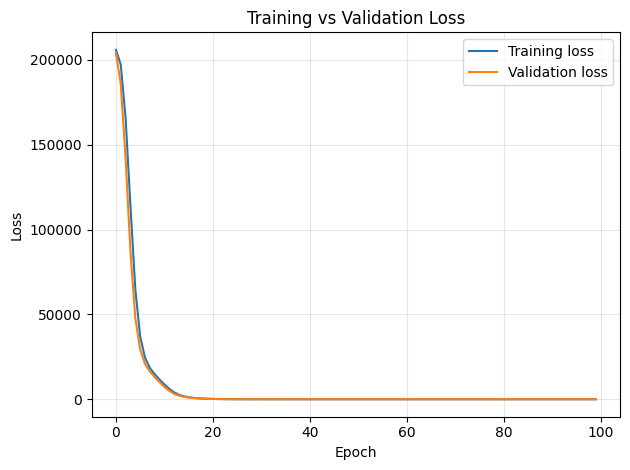

In [20]:
import matplotlib.pyplot as plt 

loss_df = pd.DataFrame({
    "training_loss" :train_loss,
    "validation_loss" : valid_loss 
})

plt.plot(loss_df["training_loss"],label ="Training loss")
plt.plot(loss_df["validation_loss"],label ="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

loading and save the best model

In [21]:
# 100 - epochs 
# multiple batches
train_loss = []
valid_loss = []
best_model = float("inf")
num_epochs = 100 
for epoch in range(num_epochs):
    model.train()   # there are various of model of models 
    running_loss = 0.0  # total training loss for 1 epoch
    for xb, yb in train_loader:
        # xb = feature of 1 batches 
        # yb = label of 1 batches
        optimizer.zero_grad()
        output = model(xb) # predicated output batch

        # loss 
        loss = crieteria(output,yb)
        loss.backward() # back propagation
        optimizer.step() # update 

        running_loss += loss.item() # loss is tensor so , tensor -> py float
    epoch_training_loss = running_loss/len(train_loader)
    train_loss.append(epoch_training_loss)
    


    model.eval()
    # validation 
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            # xb = feature of 1 batches 
            # yb = label of 1 batches
            output = model(xb) # predicated output batch

            # loss 
            loss = crieteria(output,yb)
            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss/len(test_loader)
    valid_loss.append(epoch_val_loss)
    print(f"epoch {epoch+1}/{num_epochs} ==> train loss = {epoch_training_loss} & val loss = {epoch_val_loss}")
    if epoch_val_loss < best_model:
        best_model = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")




epoch 1/100 ==> train loss = 21.447544157505035 & val loss = 20.82599665323893
epoch 2/100 ==> train loss = 21.366515489419303 & val loss = 19.814274152119953
epoch 3/100 ==> train loss = 21.581541645526887 & val loss = 20.11715784072876
epoch 4/100 ==> train loss = 21.452309743563333 & val loss = 20.180883089701336
epoch 5/100 ==> train loss = 21.561883064111075 & val loss = 20.064306354522706
epoch 6/100 ==> train loss = 21.3646364569664 & val loss = 19.834036604563394
epoch 7/100 ==> train loss = 22.229582154750823 & val loss = 19.87577838897705
epoch 8/100 ==> train loss = 21.460368533929188 & val loss = 20.940064350763958
epoch 9/100 ==> train loss = 21.51783794959386 & val loss = 19.783080291748046
epoch 10/100 ==> train loss = 21.387207170327503 & val loss = 19.595910406112672
epoch 11/100 ==> train loss = 21.397349178791046 & val loss = 20.469230079650877
epoch 12/100 ==> train loss = 21.47555499871572 & val loss = 20.064266951878867
epoch 13/100 ==> train loss = 21.35154629151

In [22]:
model.load_state_dict(torch.load("best_model.pt", weights_only=False))

<All keys matched successfully>

Evaluation 

In [28]:
model.eval()

with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crieteria(train_pred, y_train_tensor)
    test_mse_loss = crieteria(test_pred, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Test MSE:", test_mse_loss.item())

Training MSE: 21.20067596435547
Test MSE: 19.548412322998047


In [29]:
from sklearn.metrics import r2_score
print(r2_score(y_test,test_pred))

0.9316833471336382
